# 🎓 Student Study Schedule Optimization Using Genetic Algorithm

**OTML Mini Project**

This project uses a Genetic Algorithm (GA) to create an optimized study schedule based on subject difficulty, priority, exam urgency, and required study hours.

### Main OTML concepts
- Optimization problem
- Objective/Fitness function
- Genetic Algorithm
- Population and chromosome
- Selection
- Crossover
- Mutation
- Generations and convergence


## 1. Project Objective

To generate a study schedule that gives more study time to difficult, high-priority, and near-exam subjects while respecting the student's available study hours.

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Student and Subject Data

You can change these values according to your own subjects.

In [ ]:
subjects = pd.DataFrame({
    'Subject': ['Machine Learning', 'DAA', 'DBMS', 'ATCD', 'BEOD'],
    'Difficulty': [5, 5, 4, 4, 2],
    'Priority': [5, 5, 4, 3, 2],
    'Exam_Days_Left': [8, 10, 12, 15, 20],
    'Required_Hours': [10, 8, 7, 6, 3]
})

AVAILABLE_HOURS_PER_DAY = 6
NUMBER_OF_DAYS = 7
SLOT_HOURS = 1
TOTAL_SLOTS = AVAILABLE_HOURS_PER_DAY * NUMBER_OF_DAYS

subjects

,Subject,Difficulty,Priority,Exam_Days_Left,Required_Hours
0,Machine Learning,5,5,8,10
1,DAA,5,5,10,8
2,DBMS,4,4,12,7
3,ATCD,4,3,15,6
4,BEOD,2,2,20,3


## 3. Create Subject Weights

Higher weight means the subject should receive more attention. The weight combines difficulty, priority, and exam urgency.

In [ ]:
max_exam_days = subjects['Exam_Days_Left'].max()
subjects['Urgency'] = 1 / subjects['Exam_Days_Left']
subjects['Urgency_Normalized'] = subjects['Urgency'] / subjects['Urgency'].max()

subjects['Weight'] = (
    0.40 * subjects['Difficulty'] / subjects['Difficulty'].max()
    + 0.35 * subjects['Priority'] / subjects['Priority'].max()
    + 0.25 * subjects['Urgency_Normalized']
)

subjects[['Subject', 'Difficulty', 'Priority', 'Exam_Days_Left', 'Required_Hours', 'Weight']]

,Subject,Difficulty,Priority,Exam_Days_Left,Required_Hours,Weight
0,Machine Learning,5,5,8,10,1.000000
1,DAA,5,5,10,8,0.950000
2,DBMS,4,4,12,7,0.766667
3,ATCD,4,3,15,6,0.663333
4,BEOD,2,2,20,3,0.400000


## 4. Genetic Algorithm Representation

One chromosome represents one possible timetable. Each gene represents one 1-hour study slot and stores the subject assigned to that slot.

In [ ]:
subject_names = subjects['Subject'].tolist()
subject_to_idx = {name: i for i, name in enumerate(subject_names)}

def create_chromosome():
    # Start with a random assignment for every available 1-hour slot.
    return [random.choice(subject_names) for _ in range(TOTAL_SLOTS)]

population_size = 60
population = [create_chromosome() for _ in range(population_size)]

print('Example chromosome:')
print(population[0])
print('Population size:', len(population))

Example chromosome:
['Machine Learning', 'Machine Learning', 'DBMS', 'DAA', 'DAA', 'DAA', 'Machine Learning', 'BEOD', 'Machine Learning', 'BEOD', 'ATCD', 'Machine Learning', 'Machine Learning', 'Machine Learning', 'DAA', 'DAA', 'BEOD', 'BEOD', 'Machine Learning', 'BEOD', 'DAA', 'BEOD', 'ATCD', 'DAA', 'ATCD', 'BEOD', 'DBMS', 'Machine Learning', 'DAA', 'ATCD', 'DBMS', 'DBMS', 'DAA', 'DAA', 'DBMS', 'Machine Learning', 'Machine Learning', 'ATCD', 'Machine Learning', 'DBMS', 'DBMS', 'BEOD']
Population size: 60


## 5. Fitness Function ⭐

The fitness function rewards schedules that:
1. Give hours according to subject weights.
2. Cover required study hours.
3. Avoid over-studying one subject.

Higher fitness = better schedule.

In [ ]:
weight_map = dict(zip(subjects['Subject'], subjects['Weight']))
required_map = dict(zip(subjects['Subject'], subjects['Required_Hours']))

def fitness(chromosome):
    counts = {s: chromosome.count(s) for s in subject_names}
    score = 0.0

    total_required = subjects['Required_Hours'].sum()
    total_available = TOTAL_SLOTS

    for s in subject_names:
        allocated = counts[s]
        required = required_map[s]

        # Reward allocation toward required hours.
        coverage = min(allocated, required) / required
        score += 50 * coverage

        # Reward allocation to important subjects.
        score += 25 * (allocated / total_available) * weight_map[s]

        # Penalize excessive hours beyond the requirement.
        if allocated > required:
            score -= 8 * (allocated - required)

    # Small penalty if too many slots are concentrated in one subject.
    max_allowed = max(required_map.values()) + 2
    for s in subject_names:
        if counts[s] > max_allowed:
            score -= 3 * (counts[s] - max_allowed)

    return score

print('Fitness of first chromosome:', round(fitness(population[0]), 2))

Fitness of first chromosome: 189.54


## 6. Selection

Tournament selection chooses several random schedules and keeps the one with the highest fitness.

In [ ]:
def selection(population, tournament_size=4):
    candidates = random.sample(population, tournament_size)
    return max(candidates, key=fitness).copy()

## 7. Crossover

Two parent schedules are combined to create a child schedule.

In [ ]:
def crossover(parent1, parent2):
    point = random.randint(1, TOTAL_SLOTS - 1)
    child = parent1[:point] + parent2[point:]
    return child

## 8. Mutation

Mutation randomly changes a few study slots. This helps the algorithm explore new solutions.

In [ ]:
def mutate(chromosome, mutation_rate=0.05):
    child = chromosome.copy()
    for i in range(len(child)):
        if random.random() < mutation_rate:
            child[i] = random.choice(subject_names)
    return child

## 9. Run the Genetic Algorithm

We will run the algorithm for 100 generations and keep the best solution from each generation.

In [ ]:
GENERATIONS = 100
ELITE_COUNT = 4
MUTATION_RATE = 0.05

population = [create_chromosome() for _ in range(population_size)]
best_solution = None
best_score = float('-inf')
fitness_history = []

for generation in range(GENERATIONS):
    ranked = sorted(population, key=fitness, reverse=True)
    generation_best = ranked[0]
    generation_score = fitness(generation_best)

    if generation_score > best_score:
        best_score = generation_score
        best_solution = generation_best.copy()

    fitness_history.append(best_score)

    new_population = [x.copy() for x in ranked[:ELITE_COUNT]]

    while len(new_population) < population_size:
        parent1 = selection(population)
        parent2 = selection(population)
        child = crossover(parent1, parent2)
        child = mutate(child, MUTATION_RATE)
        new_population.append(child)

    population = new_population

print('Optimization completed!')
print('Best fitness:', round(best_score, 2))

Optimization completed!
Best fitness: 207.12


## 10. Convergence Graph

This graph shows how the best fitness improves across generations.

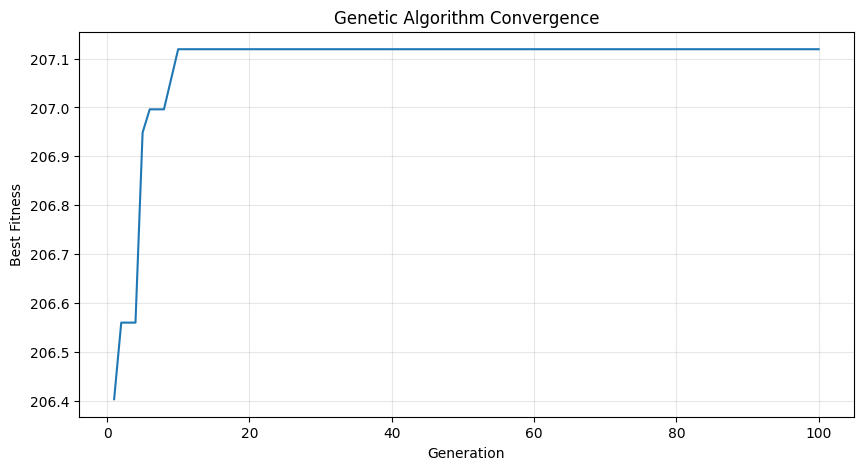

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, GENERATIONS + 1), fitness_history)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.grid(True, alpha=0.3)
plt.show()

## 11. Convert Best Chromosome into a Weekly Timetable

In [ ]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
time_slots = [
    '6:00-7:00', '7:00-8:00', '10:00-11:00',
    '4:00-5:00', '6:00-7:00', '8:00-9:00'
]

schedule_rows = []
index = 0

for day in days:
    for time in time_slots:
        schedule_rows.append({
            'Day': day,
            'Time': time,
            'Subject': best_solution[index]
        })
        index += 1

schedule_df = pd.DataFrame(schedule_rows)
schedule_df

,Day,Time,Subject
0,Monday,6:00-7:00,ATCD
1,Monday,7:00-8:00,DBMS
2,Monday,10:00-11:00,ATCD
3,Monday,4:00-5:00,Machine Learning
4,Monday,6:00-7:00,BEOD
5,Monday,8:00-9:00,Machine Learning
6,Tuesday,6:00-7:00,DAA
7,Tuesday,7:00-8:00,DBMS
8,Tuesday,10:00-11:00,Machine Learning
9,Tuesday,4:00-5:00,Machine Learning


## 12. Subject-wise Allocated Hours

In [ ]:
allocated = schedule_df['Subject'].value_counts().reindex(subject_names, fill_value=0)

comparison = subjects[['Subject', 'Required_Hours']].copy()
comparison['Allocated_Hours'] = comparison['Subject'].map(allocated)
comparison['Difference'] = comparison['Allocated_Hours'] - comparison['Required_Hours']

comparison

,Subject,Required_Hours,Allocated_Hours,Difference
0,Machine Learning,10,12,2
1,DAA,8,12,4
2,DBMS,7,9,2
3,ATCD,6,6,0
4,BEOD,3,3,0


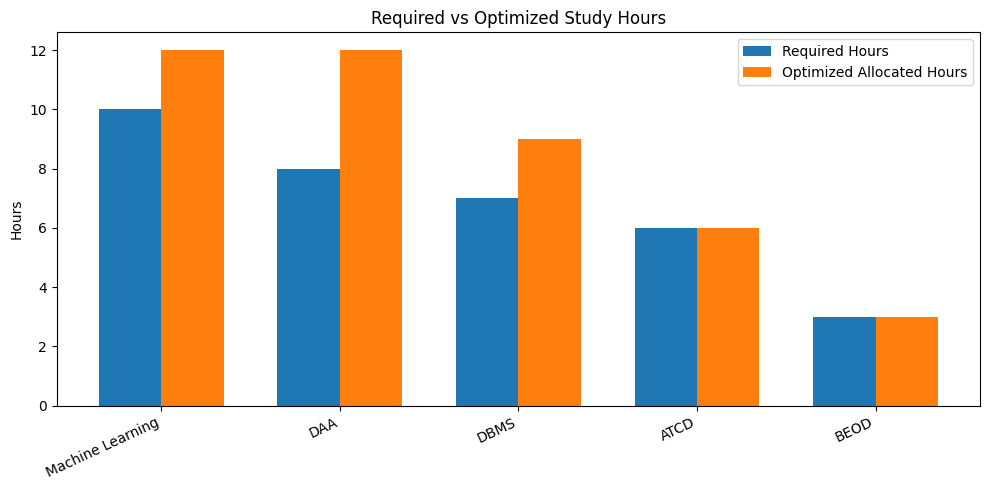

In [ ]:
plt.figure(figsize=(10, 5))
x = np.arange(len(subject_names))
width = 0.35
plt.bar(x - width/2, comparison['Required_Hours'], width, label='Required Hours')
plt.bar(x + width/2, comparison['Allocated_Hours'], width, label='Optimized Allocated Hours')
plt.xticks(x, subject_names, rotation=25, ha='right')
plt.ylabel('Hours')
plt.title('Required vs Optimized Study Hours')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Final Result

The final output is an optimized weekly study schedule generated by the Genetic Algorithm.

### Conclusion
The Genetic Algorithm searches through many possible study schedules and improves them using selection, crossover, and mutation. The fitness function guides the search toward schedules that prioritize difficult, important, and near-exam subjects while respecting the available study time.

### Future Scope
- Add breaks and sleep constraints.
- Add student's preferred study times.
- Add revision sessions before exams.
- Build a Streamlit web application.
- Compare Genetic Algorithm with Particle Swarm Optimization or Simulated Annealing.

## Viva Points

**Q1. Why Genetic Algorithm?**  
Because timetable scheduling is a search/optimization problem with many possible combinations, and GA can efficiently search for a good solution.

**Q2. What is a chromosome?**  
A chromosome represents one possible study schedule.

**Q3. What is fitness?**  
Fitness is a score that measures how good a schedule is.

**Q4. What is crossover?**  
Crossover combines parts of two parent schedules to create a new schedule.

**Q5. What is mutation?**  
Mutation randomly changes some genes to maintain diversity and explore new solutions.
